#### Carga de Entorno y Buffer de Datos

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

tf.config.set_visible_devices([], 'GPU')
print("Dispositivos configurados para inferencia secuencial: CPU")

print("1. Cargando modelo entrenado y pipeline de escalado...")
model = tf.keras.models.load_model('mlp_binario_final.h5')
scaler = joblib.load('standard_scaler_binario.pkl')

print("2. Cargando buffer de tráfico real (Holdout 10%)...")
df_real = pd.read_feather("test_real_traffic.feather")

# Las 18 características que el modelo espera recibir
FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size', 
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration', 
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count' 
]

# Limpiar posibles datos corruptos
df_real = df_real.dropna(subset=FEATURES_SELECCIONADAS + ['label'])

# Generar etiqueta binaria (ground truth) que usaremos SOLO para constatar, NO para predecir
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'
df_real['label_binario'] = (df_real['label'] != NOMBRE_CLASE_BENIGNA).astype(int)

print("3. Barajando paquetes para simular red estocástica...")
# Frac=1 toma el 100% de los datos pero los desordena aleatoriamente.
# Al iterar sobre este dataframe, garantizamos que no se repitan paquetes.
df_real = df_real.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total de paquetes en el buffer de transmisión listos para ser enviados: {len(df_real)}")

Dispositivos configurados para inferencia secuencial: CPU
1. Cargando modelo entrenado y pipeline de escalado...
2. Cargando buffer de tráfico real (Holdout 10%)...
3. Barajando paquetes para simular red estocástica...
Total de paquetes en el buffer de transmisión listos para ser enviados: 4668658


#### Simulador de Inyección e Inferencia (Bucle Principal)
Nota: Antes de correr esta celda, ajusta INTERVALO_SEGUNDOS. Para estresar el sistema, ponle 0.0. Para ver el tráfico a una velocidad humana, ponle 0.1 o 0.5. Cuando quieras parar, presiona el botón "Stop / Interrumpir Kernel" (■) de tu entorno Jupyter.

In [2]:
# =====================================================================
# CONFIGURACIÓN DEL GENERADOR DE TRÁFICO
# Tiempo de espera entre paquetes (segundos). 
# 0.0 = Estrés máximo (ráfaga continua asincrónica).
# =====================================================================
INTERVALO_SEGUNDOS = 0.004  # Cambia este valor para simular diferentes velocidades de inyección  

# Variables para acumular métricas
paquetes_procesados = 0
y_true_list = []
y_pred_list = []
tiempos_inferencia = []

print("Iniciando simulador de IDS Pasivo en 3 segundos...")
print("⚠️ IMPORTANTE: Presiona el botón 'Detener Kernel' (el cuadrado negro ■) para detener el flujo y ver resultados.")
time.sleep(3)

try:
    for idx, row in df_real.iterrows():
        # 1. Separación estricta: Extraer SOLO las características (sin el label)
        # Se formatea como matriz [1, 18] que es lo que espera Keras
        X_raw = row[FEATURES_SELECCIONADAS].values.reshape(1, -1) 
        
        # Guardamos la verdad para constatar después
        y_true = int(row['label_binario'])
        tipo_ataque_real = row['label']

        # 2. Preprocesamiento emulado en tiempo real
        X_scaled = scaler.transform(X_raw)

        # 3. Inferencia de red neuronal (Midiendo latencia estrictamente)
        t0_inf = time.time()
        
        # y_prob = model.predict(X_scaled, verbose=0)
        y_prob = model(X_scaled, training=False).numpy()
        y_pred = int(y_prob[0][0] > 0.5)
        t_fin = time.time()

        latencia_ms = (t_fin - t0_inf) * 1000

        # Guardar registros acumulados
        tiempos_inferencia.append(latencia_ms)
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)
        paquetes_procesados += 1

        # 4. Tablero de visualización (Se actualiza para no congelar la consola)
        clear_output(wait=True)
        estado_color = "🔴 ALERTA: MALICIOSO" if y_pred == 1 else "🟢 NORMAL: PERMITIDO"
        verdad_color = "🔴 ATAQUE" if y_true == 1 else "🟢 NORMAL"
        
        print(f"==== TABLERO IDS EN TIEMPO REAL ====")
        print(f"Paquetes procesados : {paquetes_procesados}")
        print(f"Velocidad de inyección: {INTERVALO_SEGUNDOS} seg/paquete")
        print(f"------------------------------------")
        print(f"Diagnóstico IDS     : {estado_color}")
        print(f"Constatación Real   : {verdad_color} ({tipo_ataque_real})")
        print(f"Confianza de prediccion: {y_prob[0][0]:.4f}")
        print(f"------------------------------------")
        print(f"⏱️ Latencia Inferencia: {latencia_ms:.4f} ms")
        print("====================================")
        print("Presiona ■ (Detener) para finalizar y ver métricas.")

        # Simular delay de la red
        if INTERVALO_SEGUNDOS > 0:
            time.sleep(INTERVALO_SEGUNDOS)

except KeyboardInterrupt:
    clear_output(wait=True)
    print("🛑 Simulación detenida manualmente por el usuario.")
    print(f"Buffer de red pausado. Se han procesado {paquetes_procesados} paquetes en esta sesión.")

🛑 Simulación detenida manualmente por el usuario.
Buffer de red pausado. Se han procesado 64347 paquetes en esta sesión.


#### Reporte de Rendimiento Acumulado


 REPORTE FINAL DE RENDIMIENTO (PRUEBA DE ESTRÉS)

[Métricas de Latencia en Software]
➤ Latencia Promedio : 2.1106 ms
➤ Latencia Máxima   : 7.5250 ms
➤ Latencia Mínima   : 0.0000 ms
➤ Throughput Max    : 473.79 Pkts/seg

[Métricas de Precisión del Modelo]
➤ Exactitud (Accuracy) Acumulada: 98.98%

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

  Normal (0)       0.70      1.00      0.82      1499
  Ataque (1)       1.00      0.99      0.99     62848

    accuracy                           0.99     64347
   macro avg       0.85      0.99      0.91     64347
weighted avg       0.99      0.99      0.99     64347



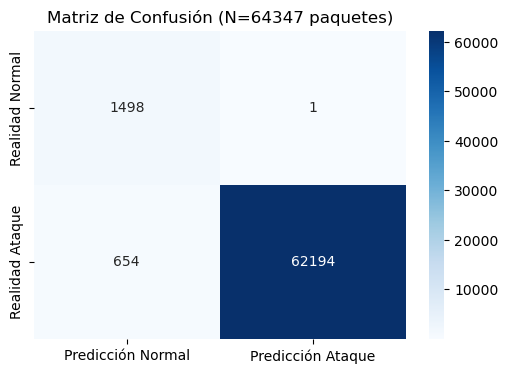

In [3]:
if paquetes_procesados > 0:
    print("\n" + "="*50)
    print(" REPORTE FINAL DE RENDIMIENTO (PRUEBA DE ESTRÉS)")
    print("="*50)
    
    # 1. Métricas de Hardware / Tiempos
    latencia_avg = np.mean(tiempos_inferencia)
    latencia_max = np.max(tiempos_inferencia)
    latencia_min = np.min(tiempos_inferencia)
    
    # Throughput (Paquetes por segundo teóricos)
    pps_teorico = 1000 / latencia_avg if latencia_avg > 0 else 0

    print("\n[Métricas de Latencia en Software]")
    print(f"➤ Latencia Promedio : {latencia_avg:.4f} ms")
    print(f"➤ Latencia Máxima   : {latencia_max:.4f} ms")
    print(f"➤ Latencia Mínima   : {latencia_min:.4f} ms")
    print(f"➤ Throughput Max    : {pps_teorico:.2f} Pkts/seg")
    
    # 2. Métricas de Inteligencia Artificial
    print("\n[Métricas de Precisión del Modelo]")
    acc = accuracy_score(y_true_list, y_pred_list)
    print(f"➤ Exactitud (Accuracy) Acumulada: {acc*100:.2f}%\n")
    
    print("Reporte de Clasificación Detallado:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Normal (0)', 'Ataque (1)'], zero_division=0))

    # 3. Matriz de Confusión
    cm = confusion_matrix(y_true_list, y_pred_list)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicción Normal', 'Predicción Ataque'], 
                yticklabels=['Realidad Normal', 'Realidad Ataque'])
    plt.title(f'Matriz de Confusión (N={paquetes_procesados} paquetes)')
    plt.show()

else:
    print("No se procesaron datos. Inicia la celda anterior para correr la simulación.")